# Gradient Descent

## Load Advertising.csv dataset using pandas

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

df = pd.read_csv("data/Advertising.csv", index_col = 0)
df.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## Standardize each column of the dataset
Ensure that data is centered around zero and std is always 1.

In [5]:
# Separate X and Y
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Standardize
X = scale(X)

X[:5]

array([[ 0.96985227,  0.98152247,  1.77894547],
       [-1.19737623,  1.08280781,  0.66957876],
       [-1.51615499,  1.52846331,  1.78354865],
       [ 0.05204968,  1.21785493,  1.28640506],
       [ 0.3941822 , -0.84161366,  1.28180188]])

## Bias Term in Linear Regression
Without the column of ones Xθ, model is forced through origin (y = mx). Since the real relationship is y = b + mx, we need column of ones to learn the intercept as another weight. This allows the intercept to be updated because multiplying with 0 means we are stuck in the origin.

In [6]:
# Add column of ones for 200 rows to the left of X
X = np.c_[np.ones(X.shape[0]), X]
X[:5]

array([[ 1.        ,  0.96985227,  0.98152247,  1.77894547],
       [ 1.        , -1.19737623,  1.08280781,  0.66957876],
       [ 1.        , -1.51615499,  1.52846331,  1.78354865],
       [ 1.        ,  0.05204968,  1.21785493,  1.28640506],
       [ 1.        ,  0.3941822 , -0.84161366,  1.28180188]])

## Divide dataset into training and testing
Training = 0.85
Test = 0.25

In [114]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

print("x_train size:", x_train.shape)
print("y_train size:", y_train.shape)
print()
print("x_test size:", x_test.shape)
print("y_test size:", y_test.shape)


x_train size: (150, 4)
y_train size: (150,)

x_test size: (50, 4)
y_test size: (50,)


## Fit the model on the training set

In [115]:
# Predict: returns a vector of predicted values (matrix multiplication)
def predict (X, theta):
    # How much of the feature contributes to the prediction
    return X @ theta

In [116]:
# compute_cost: returns scalar value that tells us how accurate the model is

'''
1. compute predictions
2. compute errors
3. square errors
4. average them
'''

def compute_cost(X, y, theta):
    m = len(y) # number of training samples
    predictions = predict(X, theta)
    errors = predictions - y
    cost = (1 / (2*m)) * np.sum(errors ** 2)
    return cost

In [117]:
# compute_gradient: return matrix w that represents the partial derivative of the cost function

'''
1. compute predictions
2. compute errors
3. compute gradient
'''
# Tweak each weight so predictions are closer to real y
def compute_gradient(X, y, theta):
    m = len(y)
    predictions = predict(X, theta)
    errors = predictions - y
    # Transpose X because we want one gradient per parameter X.T -> (4, 200)
    '''
    Multiply errors by each input (including bias weight) to know how much
    to adjust each weight and average data points
    '''
    gradient = (1 / m) * (X.T @ errors)
    # Vector of directions and magnitudes for updating weights
    return gradient

In [118]:
# update_weights: returns a 4x1 matrix the contains the updated weights
'''
θ = current weights
α = learning rate
w = gradient (from compute_gradient)
'''

def update_weights(theta, gradient, alpha):
    return theta - alpha * gradient

In [119]:
# grad_descent: returns 2 matrices -> weights & cost values per iteration

'''
1. Initialize weights
2. Loop for n iterations
3. Compute gradient
4. Update weights
5. Store cost per iteration
6. Return final weights + cost history
'''

def grad_descent(X, y, alpha, iterations, init_w = None):
    m = len(y)

    if init_w is None:
        # Initialize weights to compute predictions, error, update theta
        np.random.seed(42)
        #  theta = 4 uniformly distributed numbers between 0 and 1
        init_w = np.random.rand(X.shape[1])
    else:
        init_w = init_w.copy()

    cost_history = []

    for i in range(iterations):
        gradient = compute_gradient(X, y, init_w)
        init_w = update_weights(init_w, gradient, alpha)
        cost = compute_cost(X, y, init_w)
        cost_history.append(cost)

    return init_w, cost_history
    

In [2]:
# plot_costs: plot the costs as a function of iteration

def plot_costs(cost_history):
    plt.plot(cost_history)
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.title("Cost vs Iteration")
    plt.show()

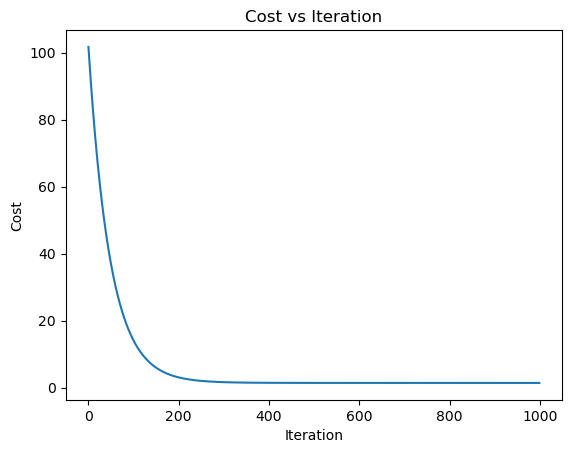

Train cost: 1.383949707864586


In [121]:
# Optimize using training data only
theta, cost_history = grad_descent(x_train, y_train, alpha = 0.01, iterations=1000, init_w=None)

# Predict y for train set and calculate cost
y_train_pred = predict(x_train, theta)
train_cost = compute_cost(x_train, y_train, theta)

plot_costs(cost_history)
print("Train cost:", train_cost)

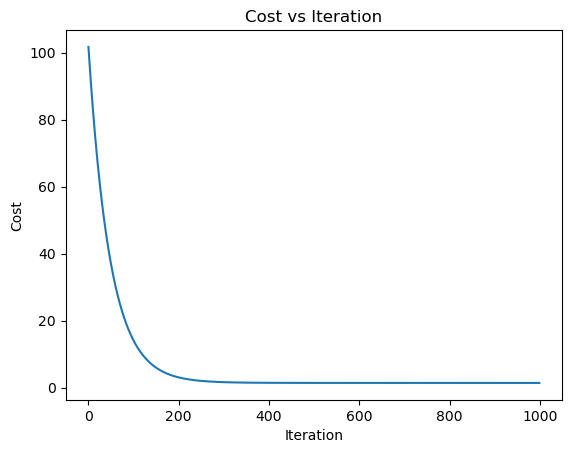

Test cost: 1.4403877686665416


In [122]:
# Predict y for test set and calculate cost

y_test_pred = predict(x_test, theta)
test_cost = compute_cost(x_test, y_test, theta)

plot_costs(cost_history)
print("Test cost:", test_cost)

## I did not standardize y so there is no need to revert to original data

# Questions

### 1. What are the optimal weights found by your implemented gradient descent? Plug it into the linear model: 


In [123]:
init_w = np.array([0.0, 0.0, 0.0, 0.0])
theta, cost_history = grad_descent(x_train, y_train, alpha = 0.01, iterations=1000, init_w=init_w)

# Predict y for train set and calculate cost
print("Optimal weights:", theta)

Optimal weights: [13.99094292  3.89130413  2.833019    0.05850791]


θ₀ -> baseline sales (when all budgets = 0)

θ₁ -> expected change in sales per standardized TV budget

θ₂ -> expected change per standardized Radio budget

θ₃ -> expected change per standardized Newspaper budget

ŷ = 13.99094292 + 3.89130413 * TV + 2.833019 * Radio + 0.05850791 * Newspaper

**What are your interpretations regarding the formed linear model?**

The expected change in sales per standardized TV budget has the highest magnitude, therefore TV budget is the predictor that influences sales the most, followed by Radio budget, and lastly the Newspaper budget.

### 2. Provide a scatter plot of the predictions vs actual for both the train and test set. Is there a trend? Provide an r2 score (also available in sklearn).

R2 = prediction accuracy

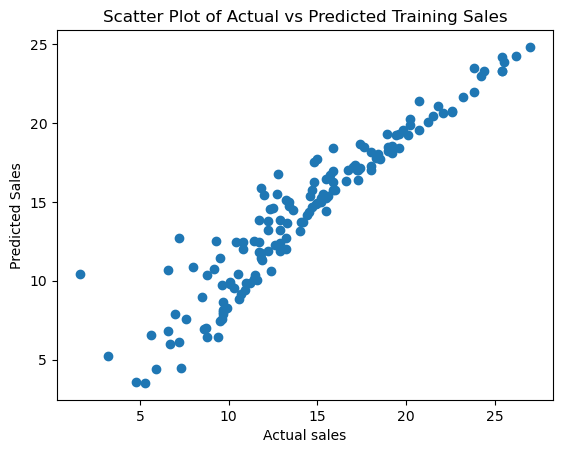

R2 Score (Train): 0.8966442414238839


In [124]:
# Train set
from sklearn.metrics import r2_score

plt.scatter(y_train, y_train_pred)
plt.xlabel('Actual sales')
plt.ylabel('Predicted Sales')
plt.title('Scatter Plot of Actual vs Predicted Training Sales')
plt.show()
print("R2 Score (Train):", r2_score(y_train, y_train_pred))

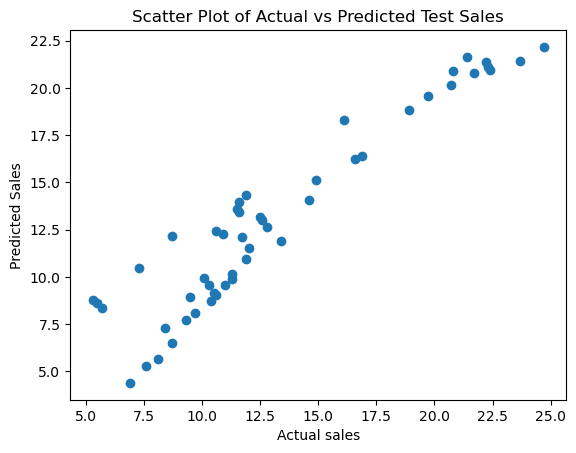

R2 Score (Test): 0.8934885353035897


In [125]:
# Test set
from sklearn.metrics import r2_score

plt.scatter(y_test, y_test_pred)
plt.xlabel('Actual sales')
plt.ylabel('Predicted Sales')
plt.title('Scatter Plot of Actual vs Predicted Test Sales')
plt.show()
print("R2 Score (Test):", r2_score(y_test, y_test_pred))

The scatter plots show a strong positive linear relationship between the actual and predicted sales for both training and test sets. The data points follow a linear trend, indicating that the model predicts sales accurately. The R^2 values are approximately 0.89, suggesting that around 89% of the variability in sales is explained by the advertising predictors. Because of this similarity in training and test R^2 values, the model generalizes accurately and does not show signs of overfitting.

### 3. What happens to the error, r2, and cost as the number of iterations increase? Show your data and proof.  You can alternatively plot your result data for visualization and check until 30000 iterations or more (actually).

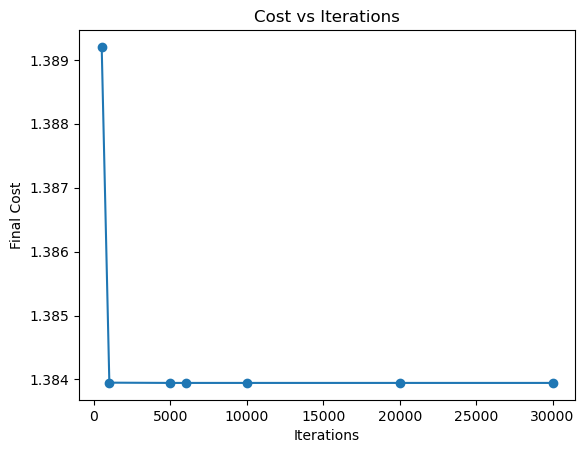

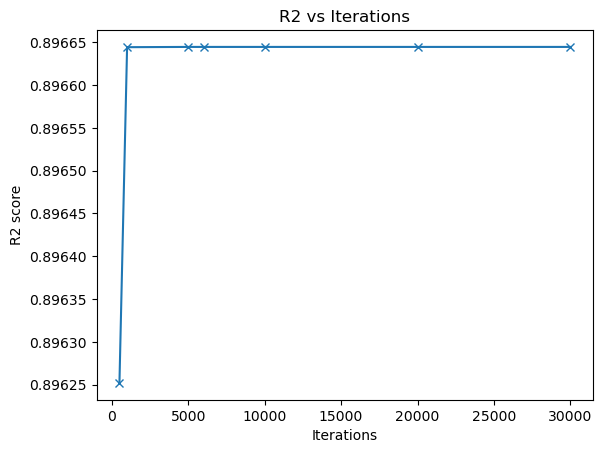

In [126]:
iterations = [500, 1000, 5000, 6000, 10000, 20000, 30000]
train_costs = []
r2_train = []

# We only check for training because this is where convergence happens
for iter in iterations:
    theta, cost_history = grad_descent(x_train, y_train, alpha = 0.01, iterations=iter, init_w=init_w)

    # Compute predictions
    y_train_pred = predict(x_train, theta)
    
    # Cost
    train_costs.append(compute_cost(x_train, y_train, theta))
    
    # r2
    r2_train.append(r2_score(y_train, y_train_pred))
    
plt.plot(iterations, train_costs, marker='o')
plt.xlabel("Iterations")
plt.ylabel("Final Cost")
plt.title("Cost vs Iterations")
plt.show()

plt.plot(iterations, r2_train, marker='x')
plt.xlabel("Iterations")
plt.ylabel("R2 score")
plt.title("R2 vs Iterations")
plt.show()

In the cost vs iterations graph, the cost is slightly higher at 500 iterations. By 1000 iterations, the cost drops sharply and from 5000 to 30000, the cost stays constant. This means that most learning happens within the first 1000 iterations and gradient descent converges quickly. After that, the following iterations give no improvements suggesting that the algorithm has reached the minimum value of the cost function.

In the r2 score vs iterations graph, R2 is slightly lower at 500 iterations. By 1000 iterations, R2 jumps sharply and from 5000 to 30000, R2 stays constant. This means that as the iterations increase, the model improves. R2 also increases and the cost decreases. After reaching the convergence point, R2 stabilizes and the following iterations do not further improve the performance.

### 4. Once you determine the optimal number of iterations, check the effect on the cost and error as you change the learning rate.  The common learning rates in machine learning include 0.1, 0.01, 0.001, 0.0001, 0.2 but you have the option to include others.  Visualize the cost function (vs the optimal number of iterations) of each learning rate in ONLY ONE PLOT.  Provide your analysis.

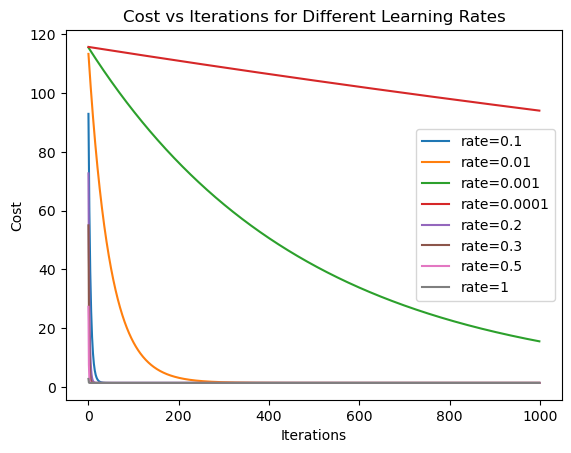

In [127]:
learning_rates = [0.1, 0.01, 0.001, 0.0001, 0.2, 0.3, 0.5, 1]

# We only check for cost curve to analyze training process
for rate in learning_rates:
    theta, cost_history = grad_descent(x_train, y_train, alpha = rate, iterations=1000, init_w=init_w)

    # Cost
    plt.plot(cost_history, label=f"rate={rate}")

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations for Different Learning Rates")
plt.legend()
plt.show()


The plot shows that the stable boundary is >= 1. Among the tested rates, the learning rate of 1 has the lowest cost function value minimized in just a few iterations or a smaller time. It follows the fastest convergence dropping to the minimum almost immediately yet it cannot be classified as unstable because there is no divergence. Between 0.1 and 0.5 learning rates are still stable and efficient - despite the aggressive curve, it still smoothly decreases, has no increase, and does not diverge. For an even lower learning rate of 0.01, there is smooth exponential decay, making it stable and predictable. Any lower than that converges extremely slowly and after 1000 iterations, they still haven't reached the minimum value, making them inefficient.

### 5.  Is there a relationship on the learning rate and the number of iterations? 

There is an inverse relationship between learning rate and the number of iterations wherein a smaller learning rate requires more iterations to converge, while a larger learning rate requires fewer iterations but risks instability. 

### 6. Compare the results with the results of ordinary least squares function.  You may use the sklearn functions: 
1. reg = LinearRegression().fit() 
2. reg.predict()

In [128]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

from sklearn.linear_model import LinearRegression
# Exclude intercept
reg = LinearRegression().fit(x_train[:,1:], y_train)

y_train_pred = reg.predict(x_train[:,1:])
y_test_pred = reg.predict(x_test[:,1:])


print("Sklearn Train Cost:", np.mean((y_train - y_train_pred)**2)/2)
print("Sklearn Test Cost:", np.mean((y_test - y_test_pred)**2)/2)
print("Sklearn R2 (Test):", reg.score(x_test[:,1:], y_test))


Sklearn Train Cost: 1.3839455390234863
Sklearn Test Cost: 1.440011865047096
Sklearn R2 (Test): 0.8935163320163658


The results are almost identical:

Train cost difference ≈ 0.000004

Test cost difference ≈ 0.00037

R² difference ≈ 0.00003

This suggests that the gradient descent implementation is correct as it converged to the same solution as the OLS. 